In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

import cv2
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [11]:
import os

# Correct path for the local dataset
main_path = "Dataset/Mango"

# Get class names from the dataset directory
class_names = sorted(os.listdir(main_path))
print(f'Class Names: {class_names}')


Class Names: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [12]:
labels=['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']

In [13]:
img_path = "Dataset/Mango"

In [14]:
img_list = []
label_list = []

for label in class_names:
    class_dir = os.path.join(img_path, label)
    for img in os.listdir(class_dir):
        img_list.append(os.path.join(class_dir, img))
        label_list.append(label)

In [15]:
# img_list = []  # List to store the full paths of image files
# label_list = []  # List to store the labels of each image file

# for label in class_names:  # Loop through each class (label)
#     for img in os.listdir(os.path.join(img_path, label)):  # List all files in the directory corresponding to the label
#         img_list.append(os.path.join(img_path, label, img))  # Append the full image path to img_list
#         label_list.append(label)  # Append the label to label_list


In [16]:
img_list[:2], label_list[:2]

(['Dataset/Mango\\Anthracnose\\20211008_124249 (Custom).jpg',
  'Dataset/Mango\\Anthracnose\\20211008_124250 (Custom).jpg'],
 ['Anthracnose', 'Anthracnose'])

In [17]:
df=pd.DataFrame({'images': img_list, 'labels': label_list})

In [18]:
df.head()

,images,labels
0,Dataset/Mango\Anthracnose\20211008_124249 (Cus...,Anthracnose
1,Dataset/Mango\Anthracnose\20211008_124250 (Cus...,Anthracnose
2,Dataset/Mango\Anthracnose\20211008_124252 (Cus...,Anthracnose
3,Dataset/Mango\Anthracnose\20211008_124253 (Cus...,Anthracnose
4,Dataset/Mango\Anthracnose\20211008_124256 (Cus...,Anthracnose


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   images  4000 non-null   object
 1   labels  4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB


<Axes: xlabel='labels', ylabel='count'>

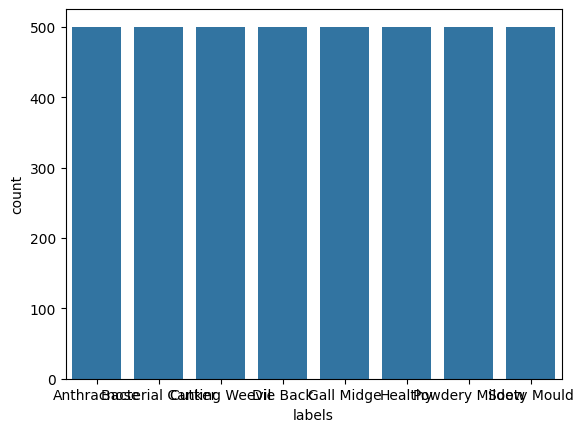

In [20]:
sns.countplot(x='labels', data=df)

In [21]:
import cv2

# List to store images
image_list = []

# Read and resize each image
for img_path in df['images']:
    img = cv2.imread(img_path)  # Read the image
    if img is not None:
        img = cv2.resize(img, (128, 128))  # Resize the image
        img = img / 255.0  # Normalize the image
        image_list.append(img)  # Append to the list
    else:
        print(f"Image path not found: {img_path}")  # Handle image not found error


In [22]:
# Convert the list to a NumPy array
x = np.array(image_list)


In [23]:
x.shape

(4000, 128, 128, 3)

In [24]:
df['labels'] = df['labels'].map({'Black Rot': 0, 'ESCA': 1, 'Healthy': 2, 'Leaf Blight':3})

In [25]:
y=df['labels']

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "Dataset/Grape",
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',   # 🔥 integer labels
    subset='training'
)

val_gen = datagen.flow_from_directory(
    "Dataset/Grape",
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu'),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Found 9600 images belonging to 4 classes.
Found 2400 images belonging to 4 classes.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_11 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_12 (Conv2D)          (None, 28, 28, 128)       73856     
                                    

In [30]:
model.save("GrapesModel.keras")


In [31]:
print("Training Loss:", history.history['loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])


Training Loss: 0.04280630871653557
Training Accuracy: 0.9864583611488342
Validation Loss: 0.039381224662065506
Validation Accuracy: 0.9891666769981384


Text(0.5, 1.0, 'Loss over Epochs')

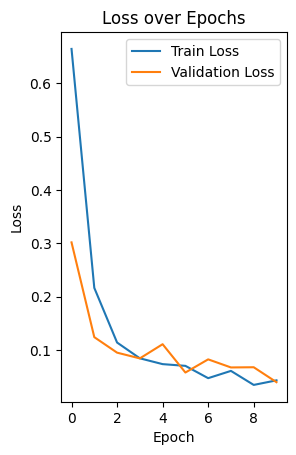

In [32]:
# Plot training and validation losses
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

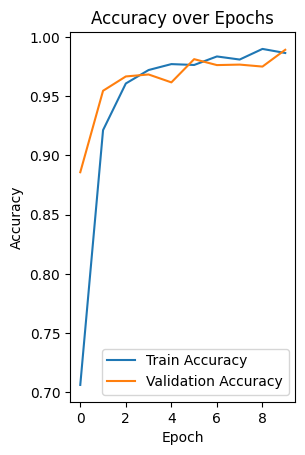

In [33]:
# Plot training and validation accuracies
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.show()


In [43]:
# Evaluate the model
test_loss, test_acc = model.evaluate(val_gen, verbose=1)
print("Test Accuracy:", test_acc)


75/75 [==============================] - 23s 300ms/step - loss: 0.0394 - accuracy: 0.9892
Test Accuracy: 0.9891666769981384


In [42]:
# Make predictions on the test data
y_preds = model.predict(x_test)


25/25 [==============================] - 7s 257ms/step


In [44]:
# Convert predictions to class labels
y_pred = np.argmax(y_preds, axis=1)


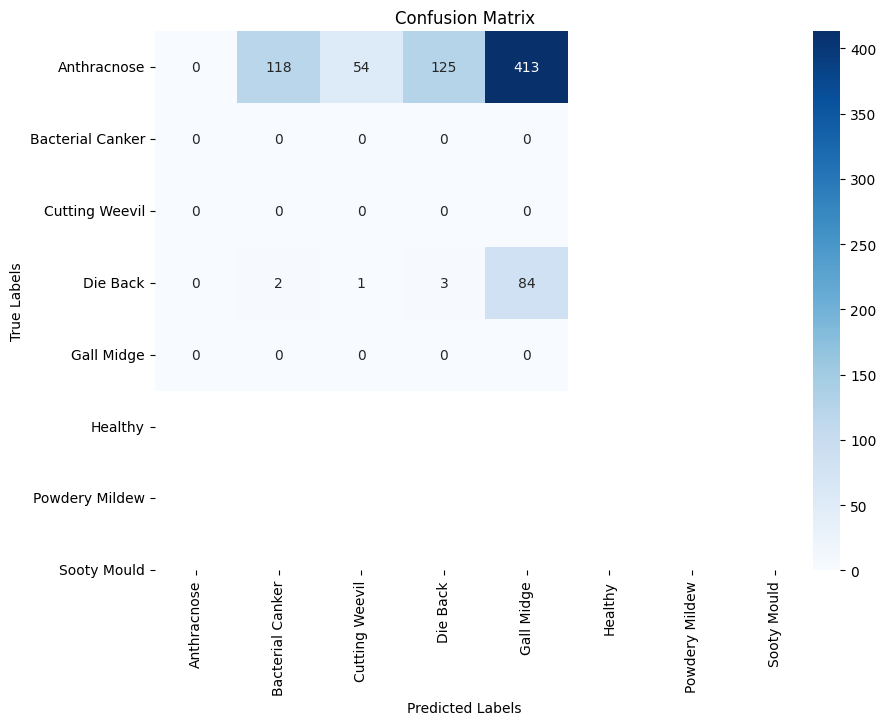

In [45]:
from sklearn.metrics import confusion_matrix

# Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:

import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np

# Load the trained Keras model
keras_model = tf.keras.models.load_model("GrapesModel.keras")
# Define the equivalent PyTorch model architecture
class GrapeNet(nn.Module):
    def __init__(self, num_classes):
        super(GrapeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3)
        self.relu5 = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 8 * 8, 512) # Adjust input size after pooling
        self.relu6 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.relu5(self.conv5(x))
        x = self.flatten(x)
        x = self.dropout(self.relu6(self.fc1(x)))
        x = self.softmax(self.fc2(x))
        return x

# Instantiate the PyTorch model with the correct number of output classes
num_classes = 4
pytorch_model = GrapeNet(num_classes)
pytorch_state_dict = {}

# Helper function to safely get weights from Keras layer
def get_keras_weights(keras_layer):
    weights = keras_layer.get_weights()
    return weights if weights else [None, None] # Handle layers without weights

# Transfer weights from Keras to PyTorch
try:
    # Convolutional layers
    keras_conv1_weights, keras_conv1_bias = get_keras_weights(keras_model.layers[0])
    pytorch_model.conv1.weight.data = torch.tensor(keras_conv1_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv1.bias.data = torch.tensor(keras_conv1_bias)

    keras_conv2_weights, keras_conv2_bias = get_keras_weights(keras_model.layers[3])
    pytorch_model.conv2.weight.data = torch.tensor(keras_conv2_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv2.bias.data = torch.tensor(keras_conv2_bias)

    keras_conv3_weights, keras_conv3_bias = get_keras_weights(keras_model.layers[6])
    pytorch_model.conv3.weight.data = torch.tensor(keras_conv3_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv3.bias.data = torch.tensor(keras_conv3_bias)

    keras_conv4_weights, keras_conv4_bias = get_keras_weights(keras_model.layers[9])
    pytorch_model.conv4.weight.data = torch.tensor(keras_conv4_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv4.bias.data = torch.tensor(keras_conv4_bias)

    keras_conv5_weights, keras_conv5_bias = get_keras_weights(keras_model.layers[12])
    pytorch_model.conv5.weight.data = torch.tensor(keras_conv5_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv5.bias.data = torch.tensor(keras_conv5_bias)

    # Dense layers
    keras_dense1_weights, keras_dense1_bias = get_keras_weights(keras_model.layers[14])
    pytorch_model.fc1.weight.data = torch.tensor(keras_dense1_weights.T)
    pytorch_model.fc1.bias.data = torch.tensor(keras_dense1_bias)

    keras_dense2_weights, keras_dense2_bias = get_keras_weights(keras_model.layers[16])
    pytorch_model.fc2.weight.data = torch.tensor(keras_dense2_weights.T)
    pytorch_model.fc2.bias.data = torch.tensor(keras_dense2_bias)

    print("Weights successfully transferred.")

except ValueError as e:
    print(f"Error during weight transfer: {e}. Please double-check layer names and shapes.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Save the PyTorch state dictionary
torch.save(pytorch_model.state_dict(), 'grapes_model.pth')
print("PyTorch model state saved to grapes_model.pth")

In [ ]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np

# Define the equivalent PyTorch model architecture
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3)
        self.relu5 = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 8 * 8, 512)
        self.relu6 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.relu5(self.conv5(x))
        x = self.flatten(x)
        x = self.dropout(self.relu6(self.fc1(x)))
        x = self.softmax(self.fc2(x))
        return x

# Load the trained Keras model
keras_model = tf.keras.models.load_model("GrapesModel.h5")

# Instantiate the PyTorch model with the correct number of output classes
num_classes = 4
pytorch_model = CNNModel(num_classes)

# Helper function to safely get weights from Keras layer
def get_keras_weights(keras_layer):
    weights = keras_layer.get_weights()
    return weights if weights else [None, None] # Handle layers without weights

# Transfer weights from Keras to PyTorch
try:
    # Convolutional layers
    keras_conv1_weights, keras_conv1_bias = get_keras_weights(keras_model.layers[0])
    pytorch_model.conv1.weight.data = torch.tensor(keras_conv1_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv1.bias.data = torch.tensor(keras_conv1_bias)

    keras_conv2_weights, keras_conv2_bias = get_keras_weights(keras_model.layers[3])
    pytorch_model.conv2.weight.data = torch.tensor(keras_conv2_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv2.bias.data = torch.tensor(keras_conv2_bias)

    keras_conv3_weights, keras_conv3_bias = get_keras_weights(keras_model.layers[6])
    pytorch_model.conv3.weight.data = torch.tensor(keras_conv3_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv3.bias.data = torch.tensor(keras_conv3_bias)

    keras_conv4_weights, keras_conv4_bias = get_keras_weights(keras_model.layers[9])
    pytorch_model.conv4.weight.data = torch.tensor(keras_conv4_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv4.bias.data = torch.tensor(keras_conv4_bias)

    keras_conv5_weights, keras_conv5_bias = get_keras_weights(keras_model.layers[12])
    pytorch_model.conv5.weight.data = torch.tensor(keras_conv5_weights.transpose(3, 2, 0, 1))
    pytorch_model.conv5.bias.data = torch.tensor(keras_conv5_bias)

    # Dense layers
    keras_dense1_weights, keras_dense1_bias = get_keras_weights(keras_model.layers[14])
    pytorch_model.fc1.weight.data = torch.tensor(keras_dense1_weights.T)
    pytorch_model.fc1.bias.data = torch.tensor(keras_dense1_bias)

    keras_dense2_weights, keras_dense2_bias = get_keras_weights(keras_model.layers[16])
    pytorch_model.fc2.weight.data = torch.tensor(keras_dense2_weights.T)
    pytorch_model.fc2.bias.data = torch.tensor(keras_dense2_bias)

    print("Weights successfully transferred.")

except ValueError as e:
    print(f"Error during weight transfer: {e}. Please double-check layer names and shapes.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Save the PyTorch state dictionary
torch.save(pytorch_model.state_dict(), 'grapes_model.pth')
print("PyTorch model state saved to grapes_model.pth")

In [3]:
import torch
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3)
        self.relu5 = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 8 * 8, 512)
        self.relu6 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.relu5(self.conv5(x))
        x = self.flatten(x)
        x = self.dropout(self.relu6(self.fc1(x)))
        x = self.softmax(self.fc2(x))
        return x

def load_model(model_path):
    num_classes = 4  # Ensure this matches your number of classes
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CNNModel(num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model, device

# Example usage in your app.py
if __name__ == '__main__':
    model_path = "grapes_model.pth"
    loaded_model, device = load_model(model_path)
    print("PyTorch model loaded successfully!")

    # You can now use loaded_model for inference
    # Example:
    # dummy_input = torch.randn(1, 3, 128, 128).to(device)
    # output = loaded_model(dummy_input)
    # print(output)

PyTorch model loaded successfully!
